# Bayesian Decoding Diagnostics

Pick a random paired interim session with at least 20 recorded cells, run the leave-one-lap-out Bayesian decoder, and inspect diagnostic plots for posterior normalization, decoded-vs-actual position, error, and real-position posterior probability.

The decoder defaults to `DECODE_GROUPBY = "condway"`, which trains separate maps for each condition-direction. The decoded-vs-actual trace can show all condition-directions together or one selected `condway`. Condition labels are read from `traj__condition` / `traj__condition__json` when available. Set `GROUP_CONDITION_FAMILIES = True` to pool condition variants into families before cross-validation (`PO`/`PO2`/`PO3`/`PONM` and `POM`/`POMB`). When `NORMALIZE_X_TO_100 = True`, cue-rich and cue-poor zones are overlaid using the same cue-zone helpers as the population geometry notebook.

In [18]:
from pathlib import Path
from collections import Counter
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'src' / 'placefields').is_dir():
    repo_root = repo_root.parent
if not (repo_root / 'src' / 'placefields').is_dir():
    raise RuntimeError('Could not find repository root containing src/placefields')

sys.path.insert(0, str(repo_root / 'src'))

from placefields import (
    BayesianDecoderConfig,
    RatemapConfig,
    build_ratemap_from_trials,
    build_regular_xbin,
    build_trial_info_from_traj,
    canonical_condition_name,
    condition_family_name,
    cue_zone_layout_for_condition,
    decode_bayesian_position_from_trials,
    decode_condway,
    ifreq_swap,
    load_traj_condition_names,
    matlab_1b_to_python_0b,
    normalize_x_to_100,
)
from placefields.interim_io import (
    find_pairs,
    load_allcel_spikes,
    load_traj_fields,
    stitch_trial_series,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

repo_root

WindowsPath('C:/Users/tadse/OneDrive/Documenti/GitHub/CA1-cellclass')

In [19]:
#Mass,  width error and correlation. 
# We need speed threshold, neuron threshold, cell type. Don't group between conditions.
# Session selection
INTERIM_ROOT = repo_root / 'data' / 'interim'
SESSION_ID = 'VS70_2023-02-24_18-36-38'          # e.g. 'VS100_2024-11-03_14-40-11'; None means random
MIN_NEURONS = 10           # Only consider sessions with at least this many recorded cells
RANDOM_SEED = 17
TRY_RANDOM_SESSIONS = 13    # If a random eligible session has no decodable windows, try another

# Decoder parameters
SPIKE_FREQ_HZ = 25_000.0
BEHAVIOR_FREQ_HZ = 1_000.0
TAU_S = 0.350
BIN_SIZE_CM = 3.0
MIN_SPEED = 2.0            # Set to None to disable speed filtering
DECODE_GROUPBY = 'condway'  # condway = condition + direction separated; condition/global are controls
GROUP_CONDITION_FAMILIES = False  # True pools PO/PO2/PO3/PONM and POM/POMB before decoding
SMOOTH_SIGMA_BINS = 3
XBIN_REM = 0
MIN_VALID_WINDOW_FRACTION = 0.5
RATE_FLOOR_HZ = 1e-12
NORMALIZE_X_TO_100 = True
TRAIN_ALL_LAPS = True  # True = train on all laps in the same condition-direction; False = leave-one-lap-out

# Cell selection. 'PYR+SMINTER' = all pyramidal cells + interneurons with SM=True in at least one SSI condition.
CELL_SELECTION_MODE = 'PYR+SMINTER'  # 'all' | 'PYR+SMINTER'
SSI_PROCESSED_ROOT = repo_root / 'data' / 'processed'

# Set to an integer for a faster draft run on large sessions; None uses all active cells.
MAX_CELLS = None

# Plot controls
TRACE_CONDWAY = 1       # None uses all condition-directions; set an int like 1 or 2 for one condway
TRACE_INCLUDE_PAIRED_DIRECTION = True  # If TRACE_CONDWAY is set, also show the matching W/B partner
MAX_TRACE_WINDOWS = None     # None uses all selected decoded windows; paired directions are balanced below
BEHAVIOR_TRACE_STRIDE = 5    # Plot every nth raw behavior sample for the actual-position trace
TRACE_TIME_MODE = 'selected_trials'  # 'selected_trials' removes between-condition gaps; 'session' keeps absolute time
TRACE_TRIAL_GAP_S = 0.0      # Gap between selected trials when TRACE_TIME_MODE='selected_trials'
TRACE_FLIP_BACKWARD_FOR_DISPLAY = 'auto'  # 'auto' flips B on the plot if raw B laps increase in stored coordinates
TRACE_SHOW_CONDITION_BLOCKS = True  # Draw vertical separators and labels for condition blocks on the trace
MAX_POSTERIOR_WINDOWS = 250
MIN_BEST_LAP_WINDOWS = 10  # Minimum decoded windows required when selecting the lowest-error lap
N_RANDOM_HEATMAP_CELLS = 5
NEURON_HEATMAP_SEED = 13
ROW_NORMALIZE_NEURON_HEATMAPS = True

In [20]:
def count_recorded_cells(allcel_path):
    _, _, id_cel = load_allcel_spikes(allcel_path)
    return int(np.asarray(id_cel).size), ''


def parse_bool_series(values):
    values = pd.Series(values)
    if values.dtype == bool:
        return values.fillna(False)
    return values.map(lambda value: str(value).strip().lower() in {'true', '1', 'yes'})


def processed_ssi_classification_path(session_id):
    mouse = str(session_id).split('_', 1)[0]
    return SSI_PROCESSED_ROOT / mouse / 'ssi' / str(session_id) / 'ssi_classification.csv'


def pyr_plus_sm_interneuron_cell_ids(session_id, available_cell_ids):
    ssi_path = processed_ssi_classification_path(session_id)
    if not ssi_path.exists():
        raise FileNotFoundError(f'Missing processed SSI classification for {session_id}: {ssi_path}')
    d = pd.read_csv(ssi_path)
    type_col = 'cell_type' if 'cell_type' in d.columns else 'pred_type' if 'pred_type' in d.columns else None
    if type_col is None:
        raise KeyError(f'{ssi_path} must contain cell_type or pred_type for PYR+SMINTER selection')
    if 'SM' not in d.columns:
        raise KeyError(f'{ssi_path} is missing SM')
    d = d.copy()
    d['cell_id'] = pd.to_numeric(d['cell_id'], errors='coerce')
    d = d.dropna(subset=['cell_id']).copy()
    d['cell_id'] = d['cell_id'].astype(np.int64)
    available = np.asarray(available_cell_ids, dtype=np.int64).ravel()
    d = d[np.isin(d['cell_id'], available)]
    d['cell_type_norm'] = d[type_col].astype(str).str.strip().str.lower()
    d['SM_bool'] = parse_bool_series(d['SM'])
    pyr_ids = set(d.loc[d['cell_type_norm'] == 'pyramidal', 'cell_id'].astype(np.int64))
    sm_inter_ids = set(d.loc[(d['cell_type_norm'] == 'interneuron') & d['SM_bool'], 'cell_id'].astype(np.int64))
    selected = np.asarray(sorted(pyr_ids.union(sm_inter_ids)), dtype=np.int64)
    meta = {
        'ssi_classification_csv': ssi_path,
        'n_pyramidal_selected': int(len(pyr_ids)),
        'n_sm_interneuron_selected': int(len(sm_inter_ids)),
    }
    return selected, meta


def select_decoder_cell_ids(session_id, available_cell_ids):
    mode = str(CELL_SELECTION_MODE).strip().lower()
    available = np.asarray(available_cell_ids, dtype=np.int64).ravel()
    if mode in {'all', ''}:
        selected = available.copy()
        meta = {'cell_selection_mode': 'all'}
    elif mode in {'pyr+sminter', 'pyr+sm_inter', 'pyr_sm_inter', 'pyr+sm-inter'}:
        selected, meta = pyr_plus_sm_interneuron_cell_ids(session_id, available)
        meta['cell_selection_mode'] = 'PYR+SMINTER'
    else:
        raise ValueError("CELL_SELECTION_MODE must be 'all' or 'PYR+SMINTER'")
    if selected.size == 0:
        raise ValueError(f'No cells selected for {session_id} with CELL_SELECTION_MODE={CELL_SELECTION_MODE!r}')
    return selected, meta


def eligible_pairs(interim_root, min_neurons):
    rows = []
    skipped = []
    for session_id, allcel_path, traj_path in find_pairs(interim_root, set()):
        try:
            n_cells, reason = count_recorded_cells(allcel_path)
        except Exception as exc:
            n_cells, reason = None, str(exc)
        if n_cells is None:
            skipped.append((session_id, allcel_path, reason))
            continue
        if n_cells >= int(min_neurons):
            rows.append((session_id, allcel_path, traj_path, n_cells))
    if skipped:
        print(f'Skipped {len(skipped)} allcel files that do not match the expected decoder schema.')
        for session_id, allcel_path, reason in skipped[:5]:
            print(f'  {session_id}: {allcel_path.name} ({reason})')
        if len(skipped) > 5:
            print(f'  ... {len(skipped) - 5} more')
    return rows


def build_condition_name_map(traj_path):
    try:
        cond_raw, names_raw = load_traj_condition_names(traj_path)
    except Exception:
        return {}

    out = {}
    for cond in np.unique(cond_raw.astype(np.int64, copy=False)):
        names = [
            canonical_condition_name(name)
            for name in names_raw[cond_raw == cond].tolist()
            if canonical_condition_name(name)
        ]
        if not names:
            continue
        counts = Counter(names)
        out[int(cond)] = sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]
    return out


def condition_label_for_condway(condway, condition_name_map):
    base_condition_1b, direction = decode_condway(int(condway))
    name = condition_name_map.get(int(base_condition_1b), f'cond{base_condition_1b}')
    return f'{name} {direction}'


def paired_direction_condway(condway):
    condway = int(condway)
    return condway + 1 if condway % 2 else condway - 1


def condition_name_for_condway(condway, condition_name_map):
    base_condition_1b, _ = decode_condway(int(condway))
    return condition_name_map.get(int(base_condition_1b), f'cond{base_condition_1b}')


def cue_layout_for_condway(condway, condition_name_map):
    name = condition_name_for_condway(condway, condition_name_map)
    return cue_zone_layout_for_condition(name, condition_family=condition_family_name(name))


def draw_cue_zones_y(ax, layout, *, show_labels=False, style='spans'):
    if style not in {'spans', 'axis_marker'}:
        raise ValueError("style must be 'spans' or 'axis_marker'")
    for start, end in layout.poor_spans:
        if style == 'spans':
            ax.axhspan(start, end, color='tab:blue', alpha=0.035, lw=0, zorder=0)
        if show_labels:
            ax.text(0.005, 0.5 * (start + end), 'poor', transform=ax.get_yaxis_transform(), va='center', ha='left', color='tab:blue', fontsize=8, alpha=0.8)
    for start, end in layout.rich_spans:
        if style == 'spans':
            ax.axhspan(start, end, color='gold', alpha=0.14, lw=0, zorder=0)
        else:
            ax.plot([-0.012, -0.012], [start, end], transform=ax.get_yaxis_transform(), color='goldenrod', lw=6, solid_capstyle='butt', clip_on=False, zorder=5)
        if show_labels:
            ax.text(0.005, 0.5 * (start + end), 'rich', transform=ax.get_yaxis_transform(), va='center', ha='left', color='goldenrod', fontsize=8, alpha=0.9)
    if style == 'spans':
        for start, end in layout.excluded_spans:
            ax.axhspan(start, end, color='0.7', alpha=0.08, lw=0, zorder=0)
    for center in layout.object_centers:
        ax.axhline(center, color='black', ls='--', lw=1.1, alpha=0.75, zorder=1)


def draw_cue_zones_x(ax, layout, *, show_labels=False):
    for start, end in layout.poor_spans:
        ax.axvspan(start, end, color='tab:blue', alpha=0.035, lw=0, zorder=2)
        if show_labels:
            ax.text(0.5 * (start + end), 0.98, 'poor', transform=ax.get_xaxis_transform(), va='top', ha='center', color='tab:blue', fontsize=8, alpha=0.8)
    for start, end in layout.rich_spans:
        ax.axvspan(start, end, color='gold', alpha=0.14, lw=0, zorder=2)
        if show_labels:
            ax.text(0.5 * (start + end), 0.98, 'rich', transform=ax.get_xaxis_transform(), va='top', ha='center', color='goldenrod', fontsize=8, alpha=0.9)
    for start, end in layout.excluded_spans:
        ax.axvspan(start, end, color='0.7', alpha=0.08, lw=0, zorder=2)
    for center in layout.object_centers:
        ax.axvline(center, color='black', ls='--', lw=1.1, alpha=0.75, zorder=3)


def run_decoder_for_pair(session_id, allcel_path, traj_path):
    itime_25k, id_spk, id_cel = load_allcel_spikes(allcel_path)
    cond, wb, start, stop, vr_list, speed_list = load_traj_fields(traj_path)
    condition_name_map = build_condition_name_map(traj_path)

    x = stitch_trial_series(start, stop, vr_list)
    if NORMALIZE_X_TO_100:
        x = normalize_x_to_100(x)

    if speed_list is None and MIN_SPEED is not None:
        raise ValueError('No XSpeed/Speed field; set MIN_SPEED=None to decode without speed filtering')
    speed = stitch_trial_series(start, stop, speed_list) if speed_list is not None else None

    trials = build_trial_info_from_traj(
        cond=cond,
        wb=wb,
        start_1b=start,
        stop_1b=stop,
        n_samples=int(x.size),
    )
    spike_idx_1b = ifreq_swap(itime_25k, SPIKE_FREQ_HZ, BEHAVIOR_FREQ_HZ)
    spike_idx_0b = matlab_1b_to_python_0b(spike_idx_1b)

    cell_ids, cell_selection_meta = select_decoder_cell_ids(session_id, id_cel)
    if MAX_CELLS is not None:
        cell_ids = cell_ids[: int(MAX_CELLS)]
        cell_selection_meta['max_cells'] = int(MAX_CELLS)
        cell_selection_meta['n_cells_after_max_cells'] = int(cell_ids.size)

    xbin_edges = build_regular_xbin(x, BIN_SIZE_CM)
    cfg = BayesianDecoderConfig(
        freq_hz=BEHAVIOR_FREQ_HZ,
        tau_s=TAU_S,
        bin_size_cm=BIN_SIZE_CM,
        min_speed=MIN_SPEED,
        smooth_sigma_bins=SMOOTH_SIGMA_BINS,
        xbin_rem=XBIN_REM,
        min_valid_window_fraction=MIN_VALID_WINDOW_FRACTION,
        rate_floor_hz=RATE_FLOOR_HZ,
        decode_groupby=DECODE_GROUPBY,
        group_condition_families=GROUP_CONDITION_FAMILIES,
        train_all_laps=TRAIN_ALL_LAPS,
    )
    result = decode_bayesian_position_from_trials(
        position_x=x,
        spike_indices_0b=spike_idx_0b,
        spike_cell_ids=id_spk,
        cell_ids=cell_ids,
        trials=trials,
        xbin_edges=xbin_edges,
        cfg=cfg,
        speed=speed,
        condition_names_by_base=condition_name_map,
    )
    context = {
        'session_id': session_id,
        'allcel_path': allcel_path,
        'traj_path': traj_path,
        'position_x': x,
        'speed': speed,
        'trials': trials,
        'spike_idx_0b': spike_idx_0b,
        'id_spk': id_spk,
        'id_cel': id_cel,
        'xbin_edges_full': xbin_edges,
        'condition_name_map': condition_name_map,
        'cell_selection_meta': cell_selection_meta,
        'n_cells_available': int(np.asarray(id_cel).size),
        'n_cells_requested': int(cell_ids.size),
    }
    return result, context


def result_to_frame(result):
    return pd.DataFrame(
        {
            'trial_index': result.trial_index_w,
            'condway': result.condway_w,
            'base_condition': [decode_condway(condway)[0] for condway in result.condway_w],
            'direction': [decode_condway(condway)[1] for condway in result.condway_w],
            'window_start': result.window_start_w,
            'window_stop': result.window_stop_w,
            'window_mid_s': 0.5 * (result.window_start_w + result.window_stop_w) / BEHAVIOR_FREQ_HZ,
            'actual_x': result.actual_x_w,
            'decoded_x': result.decoded_x_w,
            'actual_bin': result.actual_bin_w,
            'decoded_bin': result.decoded_bin_w,
            'error_cm': result.error_cm_w,
            'prob_actual': result.prob_actual_w,
            'n_spikes': result.n_spikes_w,
            'n_train_laps': result.n_train_laps_w,
            'train_group': result.train_group_w,
            'train_group_label': result.train_group_label_w.astype(str),
        }
    )


def behavior_trace_frame_for_condways(context, condways, stride=5, trial_gap_s=0.0):
    x = np.asarray(context['position_x'], dtype=float)
    trials = context['trials']
    condways = {int(condway) for condway in condways}
    stride = max(1, int(stride))
    trial_gap_s = max(0.0, float(trial_gap_s))
    condition_name_map = context.get('condition_name_map', {})
    frames = []
    selected_offset_s = 0.0
    for trial in trials:
        if int(trial.condway) not in condways:
            continue
        start = max(0, int(trial.start_idx_0b))
        stop = min(int(x.size), int(trial.stop_idx_0b_exclusive))
        if stop <= start:
            continue
        sample_index = np.arange(start, stop, stride, dtype=np.int64)
        position = x[sample_index]
        keep = np.isfinite(position)
        sample_index = sample_index[keep]
        position = position[keep]
        if sample_index.size == 0:
            continue
        base_condition, direction = decode_condway(int(trial.condway))
        condition_name = condition_name_map.get(int(base_condition), f'cond{base_condition}')
        trial_time_s = (sample_index - start) / BEHAVIOR_FREQ_HZ
        frames.append(
            pd.DataFrame(
                {
                    'trial_index': int(trial.trial_index),
                    'condway': int(trial.condway),
                    'base_condition': int(base_condition),
                    'condition_name': condition_name,
                    'condition_label': f'{condition_name} {direction}',
                    'direction': direction,
                    'trial_start_index': start,
                    'trial_stop_index': stop,
                    'selected_offset_s': selected_offset_s,
                    'sample_index': sample_index,
                    'session_time_s': sample_index / BEHAVIOR_FREQ_HZ,
                    'trial_time_s': trial_time_s,
                    'selected_time_s': selected_offset_s + trial_time_s,
                    'position_x': position,
                }
            )
        )
        selected_offset_s += (stop - start) / BEHAVIOR_FREQ_HZ + trial_gap_s
    columns = [
        'trial_index', 'condway', 'base_condition', 'condition_name', 'condition_label',
        'direction', 'trial_start_index', 'trial_stop_index',
        'selected_offset_s', 'sample_index', 'session_time_s', 'trial_time_s',
        'selected_time_s', 'position_x',
    ]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=columns)


def resolve_backward_common_axis_flip(deltas, setting='auto'):
    if isinstance(setting, str):
        normalized = setting.strip().lower()
        if normalized in {'false', 'no', '0'}:
            return False
        if normalized in {'true', 'yes', '1'}:
            return True
        if normalized != 'auto':
            raise ValueError("TRACE_FLIP_BACKWARD_FOR_DISPLAY must be 'auto', True, or False")
        delta_values = np.asarray(deltas, dtype=float)
        delta_values = delta_values[np.isfinite(delta_values)]
        return bool(delta_values.size and np.nanmedian(delta_values) > 0)
    return bool(setting)


def should_flip_backward_for_display(behavior_df, setting='auto'):
    b_df = behavior_df[behavior_df['direction'] == 'B']
    deltas = b_df.groupby('trial_index', sort=False)['position_x'].agg(lambda values: values.iloc[-1] - values.iloc[0])
    return resolve_backward_common_axis_flip(deltas.to_numpy(dtype=float), setting)


def should_flip_backward_for_context(context, setting='auto'):
    x = np.asarray(context['position_x'], dtype=float)
    deltas = []
    for trial in context['trials']:
        _, direction = decode_condway(int(trial.condway))
        if direction != 'B':
            continue
        start = max(0, int(trial.start_idx_0b))
        stop = min(int(x.size), int(trial.stop_idx_0b_exclusive))
        position = x[start:stop]
        position = position[np.isfinite(position)]
        if position.size >= 2:
            deltas.append(float(position[-1] - position[0]))
    return resolve_backward_common_axis_flip(deltas, setting)


def positions_on_common_axis(values, directions, *, x_min, x_max, flip_backward):
    out = np.asarray(values, dtype=float).copy()
    if not flip_backward:
        return out
    direction_values = np.asarray(directions).astype(str)
    if direction_values.ndim == 0:
        if str(direction_values.item()).upper() == 'B':
            out = float(x_min) + float(x_max) - out
        return out
    is_backward = np.char.upper(direction_values) == 'B'
    if is_backward.shape != out.shape:
        is_backward = np.broadcast_to(is_backward, out.shape)
    out[is_backward] = float(x_min) + float(x_max) - out[is_backward]
    return out


def spatial_array_on_common_axis(values, direction, *, flip_backward, axis=-1):
    out = np.asarray(values)
    if flip_backward and str(direction).upper() == 'B':
        return np.flip(out, axis=axis)
    return out


def condition_blocks_for_trace(behavior_df):
    if behavior_df.empty:
        return pd.DataFrame(columns=['condition_name', 'start_s', 'stop_s', 'n_laps'])
    laps = (
        behavior_df.sort_values(['plot_time_s', 'sample_index'])
        .groupby('trial_index', sort=False)
        .agg(
            condition_name=('condition_name', 'first'),
            start_s=('plot_time_s', 'min'),
            stop_s=('plot_time_s', 'max'),
        )
        .reset_index()
    )
    blocks = []
    current = None
    for row in laps.itertuples(index=False):
        if current is None or row.condition_name != current['condition_name']:
            if current is not None:
                blocks.append(current)
            current = {
                'condition_name': row.condition_name,
                'start_s': float(row.start_s),
                'stop_s': float(row.stop_s),
                'n_laps': 1,
            }
        else:
            current['stop_s'] = float(row.stop_s)
            current['n_laps'] += 1
    if current is not None:
        blocks.append(current)
    return pd.DataFrame(blocks)


def draw_condition_blocks_on_trace(ax, blocks):
    if blocks.empty:
        return
    x0, x1 = ax.get_xlim()
    min_label_width = 0.035 * max(1e-9, x1 - x0)
    for i, block in blocks.reset_index(drop=True).iterrows():
        start_s = float(block['start_s'])
        stop_s = float(block['stop_s'])
        if i > 0:
            ax.axvline(start_s, color='0.45', ls=':', lw=1.1, alpha=0.85, zorder=6)
        if stop_s - start_s >= min_label_width:
            ax.text(
                0.5 * (start_s + stop_s),
                0.985,
                str(block['condition_name']),
                transform=ax.get_xaxis_transform(),
                ha='center',
                va='top',
                fontsize=8,
                color='0.25',
                zorder=7,
            )

In [21]:
pairs = eligible_pairs(INTERIM_ROOT, MIN_NEURONS)
if not pairs:
    raise RuntimeError(f'No paired sessions with at least {MIN_NEURONS} cells under {INTERIM_ROOT}')

if SESSION_ID:
    candidates = [p for p in pairs if p[0] == SESSION_ID]
    if not candidates:
        n_found = 0
        for sid, allcel_path, _, _ in find_pairs(INTERIM_ROOT, set()):
            if sid == SESSION_ID:
                n_found, _ = count_recorded_cells(allcel_path)
                print(f'Found {n_found} cells for session {SESSION_ID}')
                n_found = 0 if n_found is None else int(n_found)
                break
        raise RuntimeError(f'SESSION_ID not found among sessions with >= {MIN_NEURONS} cells: {SESSION_ID} (found {n_found})')
else:
    rng = np.random.default_rng(RANDOM_SEED)
    order = rng.permutation(len(pairs))[: min(TRY_RANDOM_SESSIONS, len(pairs))]
    candidates = [pairs[int(i)] for i in order]

last_error = None
result = None
context = None
for session_id, allcel_path, traj_path, n_cells in candidates:
    print(f'Trying {session_id} ({n_cells} cells)')
    try:
        result, context = run_decoder_for_pair(session_id, allcel_path, traj_path)
        if result.posterior_wx.shape[0] == 0:
            raise RuntimeError('decoder returned zero windows')
        min_used_cells = min(int(MIN_NEURONS), int(context['n_cells_requested']))
        if result.cell_ids.size < min_used_cells:
            raise RuntimeError(f'decoder used only {result.cell_ids.size} active cells after filtering')
        break
    except Exception as exc:
        last_error = exc
        print(f'  skipped: {exc}')
        result = None
        context = None

if result is None or context is None:
    raise RuntimeError(f'No decodable session found in candidate set. Last error: {last_error}')

decode_df = result_to_frame(result)
condition_name_map = context['condition_name_map']
decode_df['condition_label'] = [
    condition_label_for_condway(condway, condition_name_map)
    for condway in decode_df['condway'].to_numpy()
]
print('\nSelected session:', context['session_id'])
print('allcel:', context['allcel_path'])
print('trajdata:', context['traj_path'])
print('cells available/requested/used:', context['n_cells_available'], context['n_cells_requested'], result.cell_ids.size)
print('cell selection:', context.get('cell_selection_meta', {}))
print('trials/windows/bins:', len(context['trials']), result.posterior_wx.shape[0], result.xbin_centers.size)
print('decode grouping:', DECODE_GROUPBY, '| family pooled:', GROUP_CONDITION_FAMILIES, '| train all laps:', TRAIN_ALL_LAPS)
print('posterior row-sum range:', np.sum(result.posterior_wx, axis=1).min(), np.sum(result.posterior_wx, axis=1).max())
print('condition labels:', sorted(decode_df['condition_label'].unique().tolist()))

Trying VS70_2023-02-24_18-36-38 (32 cells)

Selected session: VS70_2023-02-24_18-36-38
allcel: C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\data\interim\VS70\2023-02-24\VS70_2023-02-24_18-36-38_allcel.npz
trajdata: C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\data\interim\VS70\2023-02-24\VS70_2023-02-24_18-36-38_trajdata.npz
cells available/requested/used: 32 31 31
cell selection: {'ssi_classification_csv': WindowsPath('C:/Users/tadse/OneDrive/Documenti/GitHub/CA1-cellclass/data/processed/VS70/ssi/VS70_2023-02-24_18-36-38/ssi_classification.csv'), 'n_pyramidal_selected': 29, 'n_sm_interneuron_selected': 2, 'cell_selection_mode': 'PYR+SMINTER'}
trials/windows/bins: 70 1250 34
decode grouping: condway | family pooled: False | train all laps: True
posterior row-sum range: 0.9999999999999996 1.0000000000000004
condition labels: ['PNO B', 'PNO W', 'PO B', 'PO W', 'PO2 B', 'PO2 W']


In [22]:
summary = (
    decode_df.groupby(['condway', 'condition_label'], sort=True)
    .agg(
        n_windows=('error_cm', 'size'),
        n_laps_decoded=('trial_index', 'nunique'),
        median_error_cm=('error_cm', 'median'),
        mean_error_cm=('error_cm', 'mean'),
        mean_prob_actual=('prob_actual', 'mean'),
        mean_spikes_per_window=('n_spikes', 'mean'),
        train_group_label=('train_group_label', lambda s: ','.join(sorted(set(s.astype(str))))),
    )
    .reset_index()
)
display(summary)
display(decode_df.head())

,condway,condition_label,n_windows,n_laps_decoded,median_error_cm,mean_error_cm,mean_prob_actual,mean_spikes_per_window,train_group_label
0,1,PO W,269,15,15.152784,25.980664,0.066406,101.780669,PO W
1,2,PO B,372,15,22.032632,28.704600,0.049068,104.852151,PO B
2,3,PNO W,139,10,11.103080,25.101854,0.077153,134.417266,PNO W
3,4,PNO B,196,10,8.858613,23.450742,0.077558,127.994898,PNO B
4,5,PO2 W,147,10,10.829105,17.820180,0.093459,132.319728,PO2 W
5,6,PO2 B,127,10,11.736283,22.599132,0.089305,130.566929,PO2 B


,trial_index,condway,base_condition,direction,window_start,window_stop,window_mid_s,actual_x,decoded_x,actual_bin,decoded_bin,error_cm,prob_actual,n_spikes,n_train_laps,train_group,train_group_label,condition_label
0,0,1,1,W,11861,12211,12.036,4.022328,55.5,1,18,51.477672,0.003957,70,15,1,PO W,PO W
1,0,1,1,W,12211,12561,12.386,5.722538,49.5,1,16,43.777462,0.004678,75,15,1,PO W,PO W
2,0,1,1,W,12561,12911,12.736,10.734699,55.5,3,18,44.765301,0.049592,62,15,1,PO W,PO W
3,0,1,1,W,12911,13261,13.086,19.109212,58.5,6,19,39.390788,0.002320,52,15,1,PO W,PO W
4,0,1,1,W,13261,13611,13.436,24.684105,97.5,8,32,72.815895,0.032754,38,15,1,PO W,PO W


## Decoded Versus Actual Position

The actual-position trace is drawn from the raw behavior samples for the selected trials; decoded positions are overlaid only where the decoder produced windows. `TRACE_TIME_MODE='selected_trials'` concatenates the selected laps to avoid between-condition gaps. Condition blocks are marked with vertical dotted lines and labels when `TRACE_SHOW_CONDITION_BLOCKS=True`. Set `TRACE_CONDWAY` above to an integer to plot one condition-direction; with `TRACE_INCLUDE_PAIRED_DIRECTION = True`, the matching forward/backward partner is included too.

,condway,condition_label,direction,n_windows,n_decoded_laps,n_behavior_laps,n_behavior_samples
0,1,PO W,W,269,15,15,107117
1,2,PO B,B,372,15,15,232531


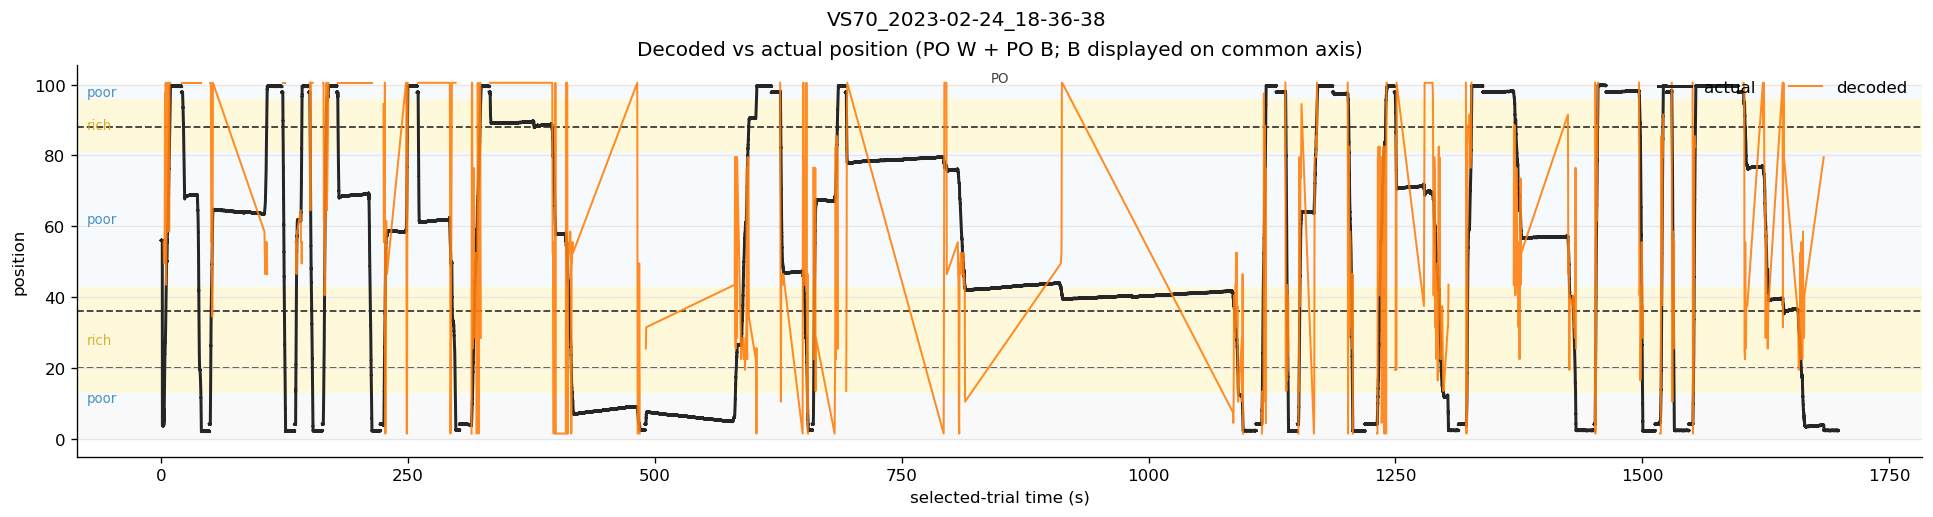

C:\Users\tadse\AppData\Local\Temp\ipykernel_25696\2052568432.py:162: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[2].boxplot(groups, labels=labels, showfliers=True)


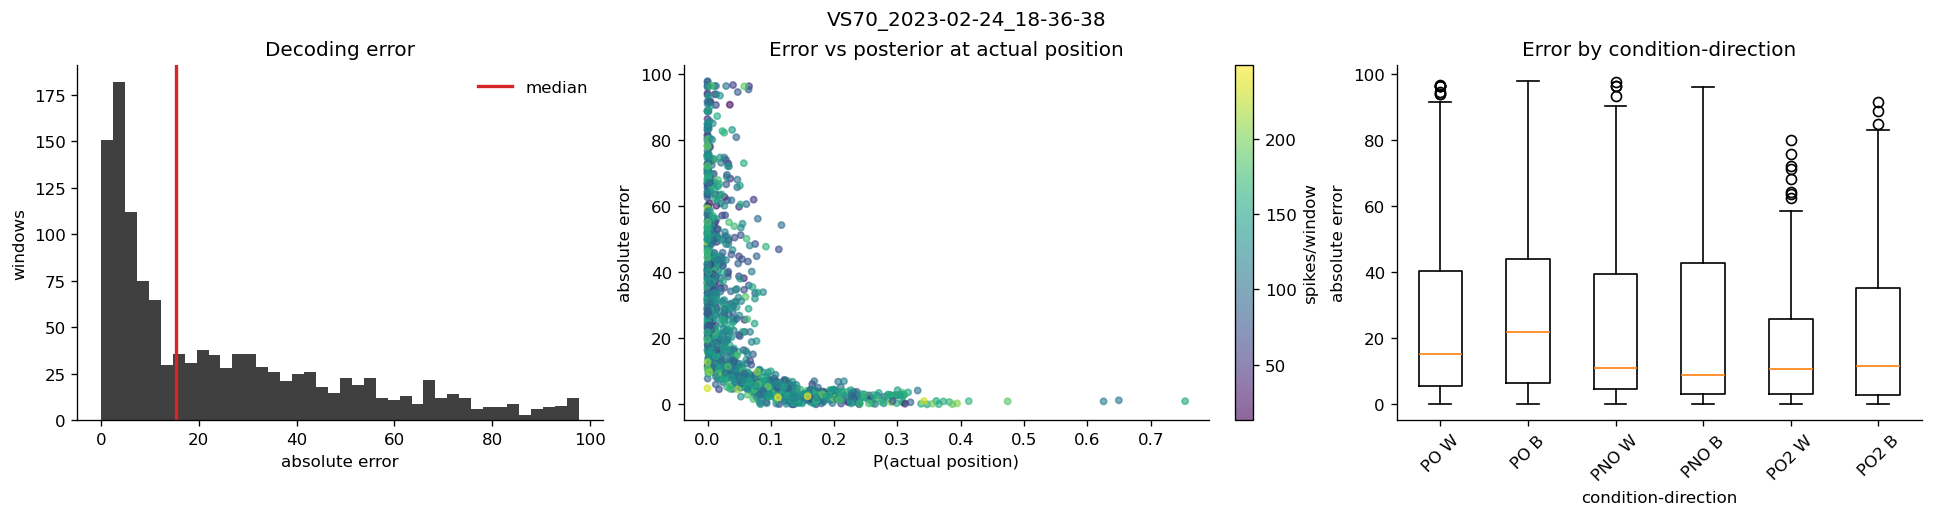

In [23]:
if 'direction' not in decode_df.columns:
    decode_df['base_condition'] = [decode_condway(condway)[0] for condway in decode_df['condway'].to_numpy()]
    decode_df['direction'] = [decode_condway(condway)[1] for condway in decode_df['condway'].to_numpy()]

if TRACE_CONDWAY is None:
    trace_condways = sorted(decode_df['condway'].unique().astype(int).tolist())
else:
    trace_condways = [int(TRACE_CONDWAY)]
    if TRACE_INCLUDE_PAIRED_DIRECTION:
        trace_condways.append(paired_direction_condway(int(TRACE_CONDWAY)))
    available_condways = set(decode_df['condway'].unique().astype(int).tolist())
    trace_condways = [condway for condway in sorted(set(trace_condways)) if condway in available_condways]

trace_source = decode_df[decode_df['condway'].isin(trace_condways)]
if trace_source.empty:
    raise RuntimeError(f'No decoded windows for TRACE_CONDWAY={TRACE_CONDWAY}; requested condways={trace_condways}')
behavior_trace_df = behavior_trace_frame_for_condways(
    context,
    trace_condways,
    stride=BEHAVIOR_TRACE_STRIDE,
    trial_gap_s=TRACE_TRIAL_GAP_S,
)
if behavior_trace_df.empty:
    raise RuntimeError(f'No behavior samples for TRACE_CONDWAY={TRACE_CONDWAY}; requested condways={trace_condways}')

behavior_counts = (
    behavior_trace_df.groupby('condway', sort=True)
    .agg(n_behavior_laps=('trial_index', 'nunique'), n_behavior_samples=('sample_index', 'size'))
    .reset_index()
)
trace_counts = (
    trace_source.groupby(['condway', 'condition_label', 'direction'], sort=True)
    .agg(n_windows=('error_cm', 'size'), n_decoded_laps=('trial_index', 'nunique'))
    .reset_index()
    .merge(behavior_counts, on='condway', how='left')
)
trace_counts[['n_behavior_laps', 'n_behavior_samples']] = trace_counts[['n_behavior_laps', 'n_behavior_samples']].fillna(0).astype(int)
display(trace_counts)

plot_df = trace_source.sort_values('window_start').reset_index(drop=True)
if MAX_TRACE_WINDOWS is None:
    trace_df = plot_df
elif TRACE_CONDWAY is not None and len(trace_condways) > 1:
    n_per_condway = max(1, int(np.ceil(MAX_TRACE_WINDOWS / len(trace_condways))))
    trace_df = (
        plot_df.groupby('condway', sort=False, group_keys=False)
        .head(n_per_condway)
        .sort_values('window_start')
        .reset_index(drop=True)
    )
else:
    trace_df = plot_df.iloc[: min(MAX_TRACE_WINDOWS, len(plot_df))]
trace_df = trace_df.copy()

trace_time_mode = str(TRACE_TIME_MODE).strip().lower()
if trace_time_mode not in {'selected_trials', 'session'}:
    raise ValueError("TRACE_TIME_MODE must be 'selected_trials' or 'session'")
trial_lookup = behavior_trace_df[
    ['trial_index', 'trial_start_index', 'selected_offset_s']
].drop_duplicates('trial_index')
trace_df = trace_df.merge(trial_lookup, on='trial_index', how='left')
if trace_df['trial_start_index'].isna().any():
    missing = trace_df.loc[trace_df['trial_start_index'].isna(), 'trial_index'].unique().tolist()
    raise RuntimeError(f'Decoded windows refer to trials missing from behavior trace: {missing[:10]}')

if trace_time_mode == 'selected_trials':
    behavior_trace_df['plot_time_s'] = behavior_trace_df['selected_time_s']
    trace_df['plot_time_s'] = trace_df['selected_offset_s'] + (
        0.5 * (trace_df['window_start'] + trace_df['window_stop']) - trace_df['trial_start_index']
    ) / BEHAVIOR_FREQ_HZ
    trace_xlabel = 'selected-trial time (s)'
else:
    behavior_trace_df['plot_time_s'] = behavior_trace_df['session_time_s']
    trace_df['plot_time_s'] = trace_df['window_mid_s']
    trace_xlabel = 'session time (s)'

x_min = float(np.nanmin(context['xbin_edges_full']))
x_max = float(np.nanmax(context['xbin_edges_full']))
flip_backward = should_flip_backward_for_context(context, TRACE_FLIP_BACKWARD_FOR_DISPLAY)
behavior_trace_df['plot_position_x'] = positions_on_common_axis(
    behavior_trace_df['position_x'], behavior_trace_df['direction'], x_min=x_min, x_max=x_max, flip_backward=flip_backward
)
trace_df['plot_decoded_x'] = positions_on_common_axis(
    trace_df['decoded_x'], trace_df['direction'], x_min=x_min, x_max=x_max, flip_backward=flip_backward
)
trace_label = (
    'all condition-directions'
    if TRACE_CONDWAY is None
    else ' + '.join(condition_label_for_condway(condway, condition_name_map) for condway in trace_condways)
)

fig_trace, ax_trace = plt.subplots(figsize=(16, 4.2), constrained_layout=True)
trace_families = {
    condition_family_name(condition_name_for_condway(condway, condition_name_map))
    for condway in trace_condways
}
if NORMALIZE_X_TO_100 and len(trace_families) == 1:
    draw_cue_zones_y(
        ax_trace,
        cue_layout_for_condway(int(trace_condways[0]), condition_name_map),
        show_labels=True,
    )
used_labels = set()
for _, trial_df in behavior_trace_df.groupby('trial_index', sort=False):
    ax_trace.plot(
        trial_df['plot_time_s'],
        trial_df['plot_position_x'],
        lw=1.8,
        color='0.15',
        label='actual' if 'actual' not in used_labels else None,
        zorder=3,
    )
    used_labels.add('actual')
for _, trial_df in trace_df.groupby('trial_index', sort=False):
    ax_trace.plot(
        trial_df['plot_time_s'],
        trial_df['plot_decoded_x'],
        lw=1.2,
        color='tab:orange',
        alpha=0.9,
        label='decoded' if 'decoded' not in used_labels else None,
        zorder=4,
    )
    used_labels.add('decoded')
if TRACE_SHOW_CONDITION_BLOCKS:
    condition_blocks = condition_blocks_for_trace(behavior_trace_df)
    draw_condition_blocks_on_trace(ax_trace, condition_blocks)
flip_note = '; B displayed on common axis' if flip_backward else ''
ax_trace.set_title(f'Decoded vs actual position ({trace_label}{flip_note})')
ax_trace.set_xlabel(trace_xlabel)
ax_trace.set_ylabel('position')
ax_trace.legend(frameon=False, ncol=2, loc='upper right')
ax_trace.grid(axis='y', color='0.9', lw=0.8)
fig_trace.suptitle(context['session_id'])
plt.show()

fig_diag, axs = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)

axs[0].hist(decode_df['error_cm'], bins=40, color='0.25')
axs[0].axvline(decode_df['error_cm'].median(), color='tab:red', lw=2, label='median')
axs[0].set_title('Decoding error')
axs[0].set_xlabel('absolute error')
axs[0].set_ylabel('windows')
axs[0].legend(frameon=False)

sc = axs[1].scatter(
    decode_df['prob_actual'],
    decode_df['error_cm'],
    c=decode_df['n_spikes'],
    s=14,
    alpha=0.6,
    cmap='viridis',
)
axs[1].set_title('Error vs posterior at actual position')
axs[1].set_xlabel('P(actual position)')
axs[1].set_ylabel('absolute error')
fig_diag.colorbar(sc, ax=axs[1], label='spikes/window')

error_groups = list(decode_df.groupby(['condway', 'condition_label'], sort=True))
groups = [g['error_cm'].to_numpy() for _, g in error_groups]
labels = [label for (_, label), _ in error_groups]
axs[2].boxplot(groups, labels=labels, showfliers=True)
axs[2].set_title('Error by condition-direction')
axs[2].set_xlabel('condition-direction')
axs[2].set_ylabel('absolute error')
axs[2].tick_params(axis='x', rotation=45)

fig_diag.suptitle(context['session_id'])
plt.show()

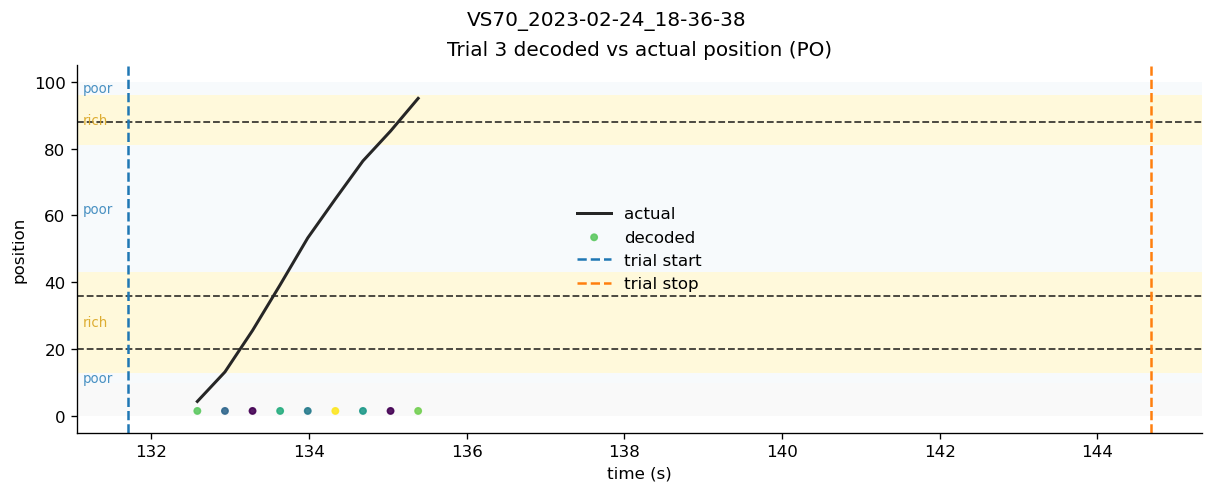

In [31]:
decode_df = decode_df
#take a random trial and filter to the windows that overlap with that trial. Plot decoded vs actual for those windows, colored by the number of spikes in the window. Show vertical lines for the trial start and stop, and shaded regions for the cue zones if available.

trial = 3
decoded_trial_df = decode_df[decode_df['trial_index'] == trial].copy()
if decoded_trial_df.empty:
    raise RuntimeError('No decoded windows for trial_index={}'.format(trial))
trial_info = context['trials'][trial]
trial_condway = int(trial_info.condway)
trial_condition_name = condition_name_for_condway(trial_condway, condition_name_map)
trial_cue_layout = cue_layout_for_condway(trial_condway, condition_name_map)
fig_trial, ax_trial = plt.subplots(figsize=(10, 4), constrained_layout=True)
draw_cue_zones_y(ax_trial, trial_cue_layout, show_labels=True)
ax_trial.plot(
    decoded_trial_df['window_mid_s'],
    decoded_trial_df['actual_x'],
    lw=1.8,
    color='0.15',
    label='actual',
    zorder=3,
)
ax_trial.scatter(
    decoded_trial_df['window_mid_s'],
    decoded_trial_df['decoded_x'],
    c=decoded_trial_df['n_spikes'],
    s=14,
    alpha=0.9,
    cmap='viridis',
    label='decoded',
    zorder=4,
)

ax_trial.axvline(trial_info.start_idx_0b / BEHAVIOR_FREQ_HZ, color='tab:blue', ls='--', lw=1.5, label='trial start')
ax_trial.axvline(trial_info.stop_idx_0b_exclusive / BEHAVIOR_FREQ_HZ, color='tab:orange', ls='--', lw=1.5, label='trial stop')
ax_trial.set_title(f'Trial {trial} decoded vs actual position ({trial_condition_name})')
ax_trial.set_xlabel('time (s)')
ax_trial.set_ylabel('position')
ax_trial.legend(frameon=False)
fig_trial.suptitle(context['session_id'])
plt.show()

## Random Neuron Heatmaps By Condition-Direction

This builds ratemaps with the same binning and speed settings as the decoder and plots 5 random active decoded neurons. Rows are neurons, columns are spatial bins, and each panel is one condition-direction.

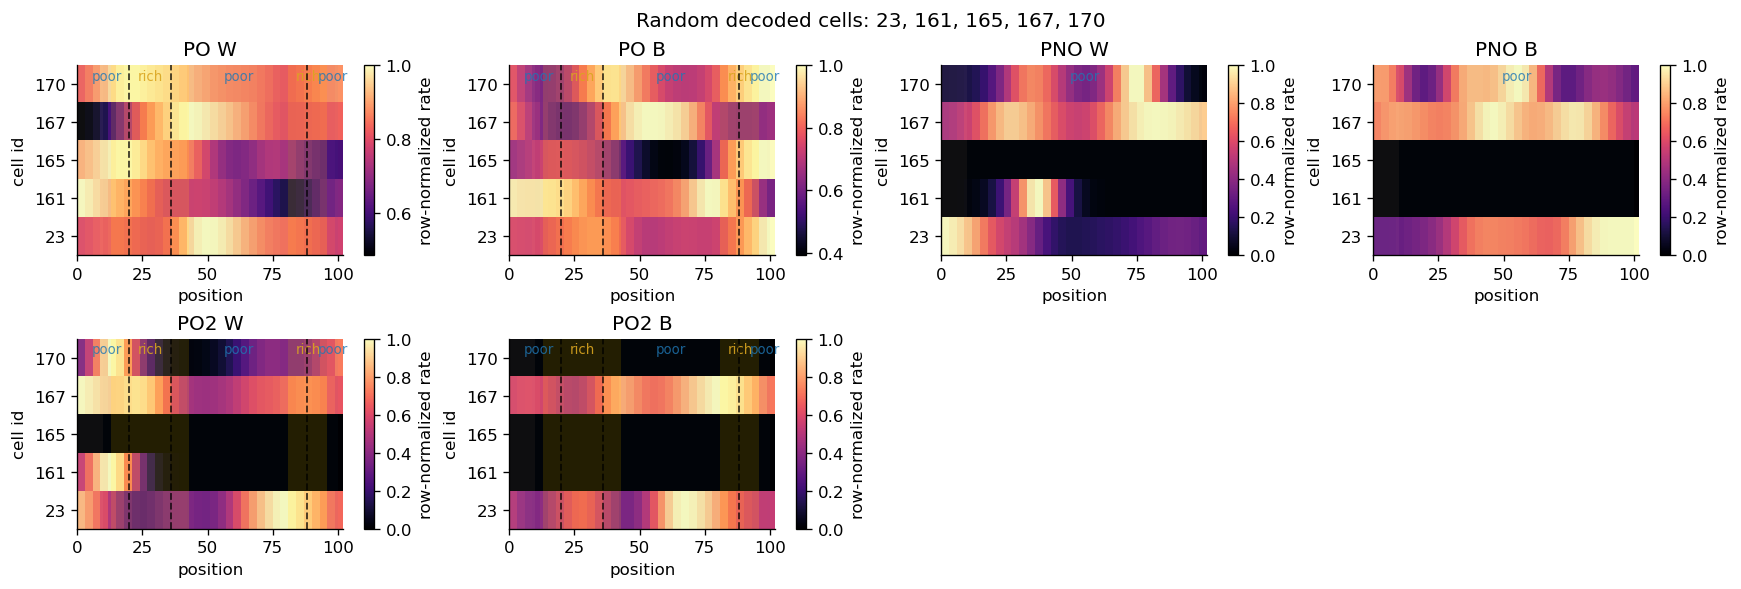

In [25]:
rmap_cfg = RatemapConfig(
    freq_hz=BEHAVIOR_FREQ_HZ,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    xbin_rem=XBIN_REM,
    nb_cond=None,
    min_speed=MIN_SPEED,
)
rmap_pack = build_ratemap_from_trials(
    position_x=context['position_x'],
    spike_indices_0b=context['spike_idx_0b'],
    spike_cell_ids=context['id_spk'],
    cell_ids=result.cell_ids,
    trials=context['trials'],
    xbin_edges=context['xbin_edges_full'],
    cfg=rmap_cfg,
    speed=context['speed'],
)

rng = np.random.default_rng(NEURON_HEATMAP_SEED)
n_show = min(int(N_RANDOM_HEATMAP_CELLS), int(result.cell_ids.size))
selected_cell_ids = np.sort(rng.choice(result.cell_ids, size=n_show, replace=False))
selected_idx = np.array([np.where(rmap_pack.cell_ids == cid)[0][0] for cid in selected_cell_ids], dtype=np.int64)
condways = sorted(set(rmap_pack.idcond_t.astype(int).tolist()))
flip_backward = should_flip_backward_for_context(context, TRACE_FLIP_BACKWARD_FOR_DISPLAY)

n_cols = min(4, len(condways))
n_rows = int(math.ceil(len(condways) / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3.6 * n_cols, 2.4 * n_rows), squeeze=False, constrained_layout=True)

for ax, condway in zip(axs.ravel(), condways):
    maps = rmap_pack.fr_s_cx_ux[selected_idx, int(condway) - 1, :].astype(float)
    if ROW_NORMALIZE_NEURON_HEATMAPS:
        denom = np.nanmax(maps, axis=1, keepdims=True)
        denom[~np.isfinite(denom) | (denom <= 0)] = 1.0
        plot_maps = maps / denom
        cbar_label = 'row-normalized rate'
    else:
        plot_maps = maps
        cbar_label = 'Hz'
    _, direction = decode_condway(int(condway))
    plot_maps = spatial_array_on_common_axis(plot_maps, direction, flip_backward=flip_backward, axis=1)
    im = ax.imshow(
        plot_maps,
        origin='lower',
        aspect='auto',
        interpolation='nearest',
        extent=[rmap_pack.xbin_edges[0], rmap_pack.xbin_edges[-1], -0.5, n_show - 0.5],
        cmap='magma',
    )
    if NORMALIZE_X_TO_100:
        draw_cue_zones_x(ax, cue_layout_for_condway(condway, condition_name_map), show_labels=True)
    ax.set_title(condition_label_for_condway(condway, condition_name_map))
    ax.set_xlabel('position')
    ax.set_yticks(np.arange(n_show))
    ax.set_yticklabels([str(cid) for cid in selected_cell_ids])
    ax.set_ylabel('cell id')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

for ax in axs.ravel()[len(condways):]:
    ax.axis('off')

fig.suptitle(f"Random decoded cells: {', '.join(map(str, selected_cell_ids.tolist()))}")
plt.show()

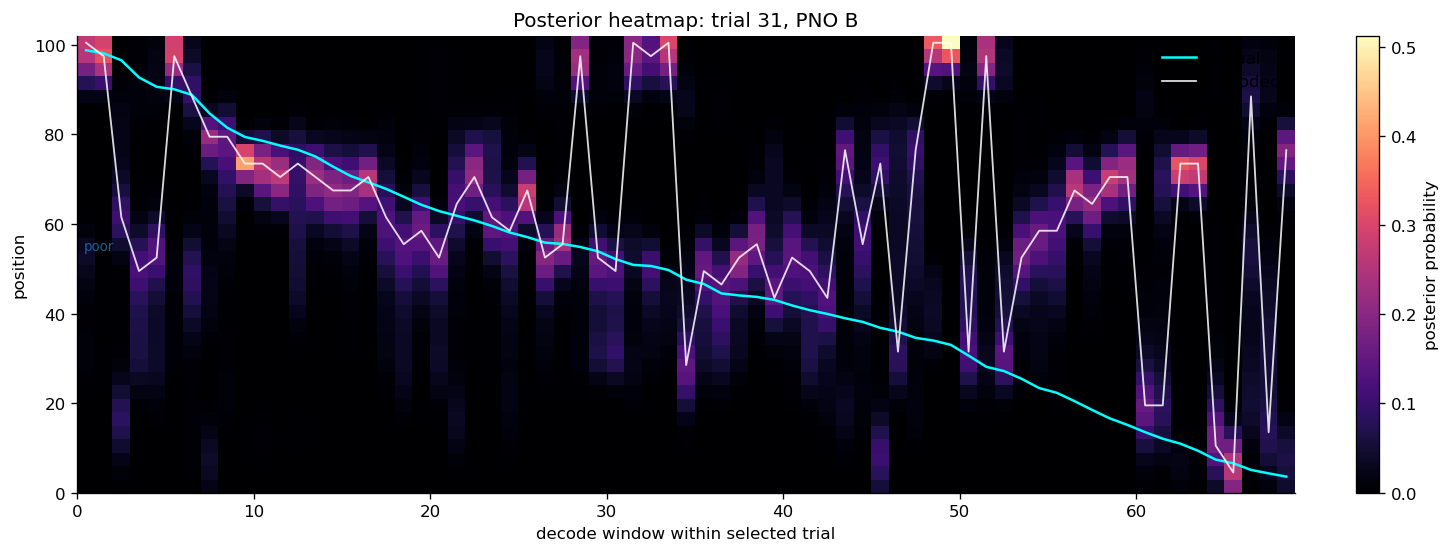

In [26]:
trial_counts = decode_df.groupby('trial_index').size().sort_values(ascending=False)
example_trial = int(trial_counts.index[0])
idx = np.flatnonzero(result.trial_index_w == example_trial)
idx = idx[: min(MAX_POSTERIOR_WINDOWS, idx.size)]

posterior_direction = decode_condway(int(result.condway_w[idx[0]]))[1]
x_min = float(np.nanmin(context['xbin_edges_full']))
x_max = float(np.nanmax(context['xbin_edges_full']))
flip_backward = should_flip_backward_for_context(context, TRACE_FLIP_BACKWARD_FOR_DISPLAY)
posterior = spatial_array_on_common_axis(result.posterior_wx[idx].T, posterior_direction, flip_backward=flip_backward, axis=0)
actual_x_plot = positions_on_common_axis(result.actual_x_w[idx], posterior_direction, x_min=x_min, x_max=x_max, flip_backward=flip_backward)
decoded_x_plot = positions_on_common_axis(result.decoded_x_w[idx], posterior_direction, x_min=x_min, x_max=x_max, flip_backward=flip_backward)
window_axis = np.arange(idx.size) + 0.5

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
im = ax.imshow(
    posterior,
    origin='lower',
    aspect='auto',
    interpolation='nearest',
    extent=[0, idx.size, result.xbin_edges[0], result.xbin_edges[-1]],
    cmap='magma',
)
if NORMALIZE_X_TO_100:
    draw_cue_zones_y(ax, cue_layout_for_condway(int(result.condway_w[idx[0]]), condition_name_map), show_labels=True, style='axis_marker')
ax.plot(window_axis, actual_x_plot, color='cyan', lw=1.5, label='actual')
ax.plot(window_axis, decoded_x_plot, color='white', lw=1.1, alpha=0.85, label='decoded')
posterior_label = condition_label_for_condway(int(result.condway_w[idx[0]]), condition_name_map)
ax.set_title(f'Posterior heatmap: trial {example_trial}, {posterior_label}')
ax.set_xlabel('decode window within selected trial')
ax.set_ylabel('position')
ax.legend(frameon=False, loc='upper right')
fig.colorbar(im, ax=ax, label='posterior probability')
plt.show()

## Best Mean-Error Lap Posterior

This selects the decoded lap with the lowest mean absolute error per decoded window, after requiring at least `MIN_BEST_LAP_WINDOWS` windows. It is a useful best-case sanity check, but it should not replace the pooled error summary above.

,trial_index,condway,condition_label,n_windows,total_abs_error_cm,mean_abs_error_cm,median_abs_error_cm,mean_prob_actual
0,58,5,PO2 W,13,162.503298,12.500254,11.948859,0.082697
1,26,1,PO W,10,125.019879,12.501988,6.279902,0.125237
2,35,4,PNO B,10,125.960644,12.596064,6.167276,0.121667
3,38,3,PNO W,12,156.854774,13.071231,7.777143,0.151589
4,65,6,PO2 B,10,136.514963,13.651496,3.190755,0.159816
5,54,5,PO2 W,27,378.793627,14.029394,4.750802,0.133348
6,41,4,PNO B,36,525.364246,14.593451,6.228658,0.110762
7,57,6,PO2 B,12,187.764449,15.647037,6.716901,0.135623
8,52,5,PO2 W,12,188.369621,15.697468,7.727211,0.096500
9,18,1,PO W,21,331.862965,15.802998,7.490540,0.095346


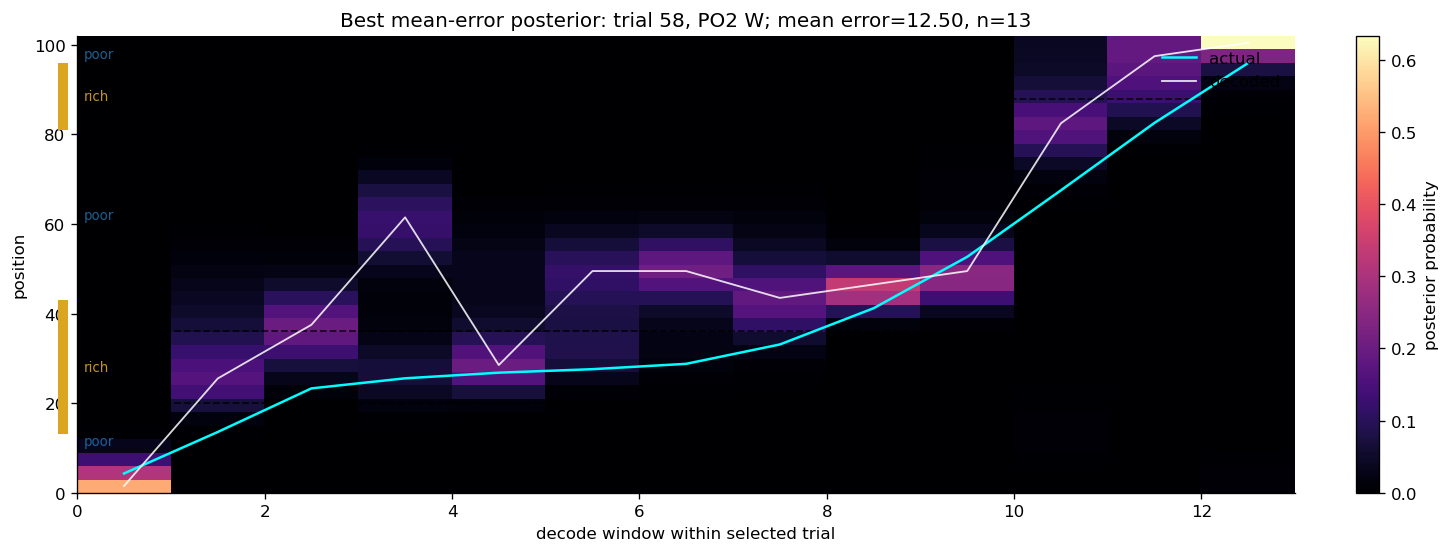

In [27]:
lap_error_df = (
    decode_df.groupby(['trial_index', 'condway', 'condition_label'], sort=False)
    .agg(
        n_windows=('error_cm', 'size'),
        total_abs_error_cm=('error_cm', 'sum'),
        mean_abs_error_cm=('error_cm', 'mean'),
        median_abs_error_cm=('error_cm', 'median'),
        mean_prob_actual=('prob_actual', 'mean'),
    )
    .reset_index()
)
eligible_lap_error_df = lap_error_df[lap_error_df['n_windows'] >= int(MIN_BEST_LAP_WINDOWS)].copy()
if eligible_lap_error_df.empty:
    raise RuntimeError(
        f'No decoded laps have at least {MIN_BEST_LAP_WINDOWS} windows; lower MIN_BEST_LAP_WINDOWS.'
    )

best_lap_row = eligible_lap_error_df.sort_values(
    ['mean_abs_error_cm', 'median_abs_error_cm', 'n_windows'],
    ascending=[True, True, False],
).iloc[0]
display(
    eligible_lap_error_df.sort_values('mean_abs_error_cm')
    .head(10)
    .reset_index(drop=True)
)

best_trial = int(best_lap_row['trial_index'])
idx = np.flatnonzero(result.trial_index_w == best_trial)
idx = idx[np.argsort(result.window_start_w[idx])]
idx = idx[: min(MAX_POSTERIOR_WINDOWS, idx.size)]

posterior_direction = decode_condway(int(result.condway_w[idx[0]]))[1]
x_min = float(np.nanmin(context['xbin_edges_full']))
x_max = float(np.nanmax(context['xbin_edges_full']))
flip_backward = should_flip_backward_for_context(context, TRACE_FLIP_BACKWARD_FOR_DISPLAY)
posterior = spatial_array_on_common_axis(result.posterior_wx[idx].T, posterior_direction, flip_backward=flip_backward, axis=0)
actual_x_plot = positions_on_common_axis(result.actual_x_w[idx], posterior_direction, x_min=x_min, x_max=x_max, flip_backward=flip_backward)
decoded_x_plot = positions_on_common_axis(result.decoded_x_w[idx], posterior_direction, x_min=x_min, x_max=x_max, flip_backward=flip_backward)
window_axis = np.arange(idx.size) + 0.5

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
im = ax.imshow(
    posterior,
    origin='lower',
    aspect='auto',
    interpolation='nearest',
    extent=[0, idx.size, result.xbin_edges[0], result.xbin_edges[-1]],
    cmap='magma',
)
if NORMALIZE_X_TO_100:
    draw_cue_zones_y(ax, cue_layout_for_condway(int(result.condway_w[idx[0]]), condition_name_map), show_labels=True, style='axis_marker')
ax.plot(window_axis, actual_x_plot, color='cyan', lw=1.5, label='actual')
ax.plot(window_axis, decoded_x_plot, color='white', lw=1.1, alpha=0.85, label='decoded')
posterior_label = condition_label_for_condway(int(result.condway_w[idx[0]]), condition_name_map)
ax.set_title(
    f'Best mean-error posterior: trial {best_trial}, {posterior_label}; '
    f'mean error={best_lap_row.mean_abs_error_cm:.2f}, n={int(best_lap_row.n_windows)}'
)
ax.set_xlabel('decode window within selected trial')
ax.set_ylabel('position')
ax.legend(frameon=False, loc='upper right')
fig.colorbar(im, ax=ax, label='posterior probability')
plt.show()

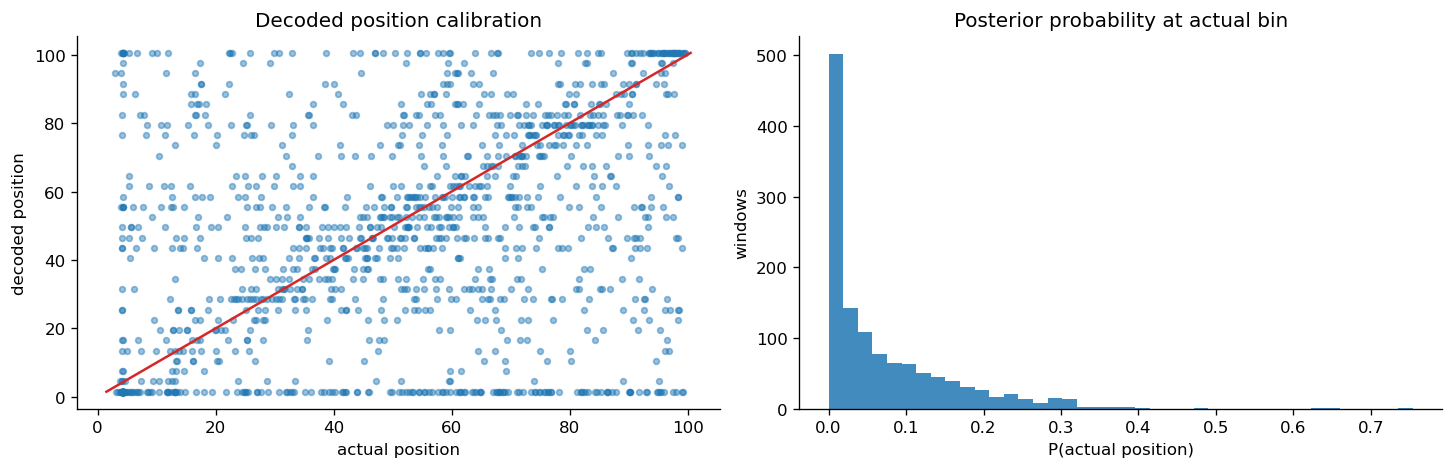

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)

axs[0].scatter(decode_df['actual_x'], decode_df['decoded_x'], s=12, alpha=0.45)
lo = min(decode_df['actual_x'].min(), decode_df['decoded_x'].min())
hi = max(decode_df['actual_x'].max(), decode_df['decoded_x'].max())
axs[0].plot([lo, hi], [lo, hi], color='tab:red', lw=1.5)
axs[0].set_title('Decoded position calibration')
axs[0].set_xlabel('actual position')
axs[0].set_ylabel('decoded position')

axs[1].hist(decode_df['prob_actual'], bins=40, color='tab:blue', alpha=0.85)
axs[1].set_title('Posterior probability at actual bin')
axs[1].set_xlabel('P(actual position)')
axs[1].set_ylabel('windows')

plt.show()

## Average Soft Confusion Matrix By Condition

For each decoded lap, this builds a soft confusion matrix by adding the full posterior vector to the row for the actual position bin. Rows are normalized within each lap, so each row estimates `P(decoded position | actual position)` for that lap. The condition matrix is then the average of those lap-level matrices, which keeps slow laps from dominating because they contain more decode windows.


,condition_label,n_trials,n_windows,mean_diagonal_mass,mean_near_diagonal_mass_10cm,expected_abs_error_cm_from_matrix,mean_row_entropy_bits
0,PNO B,10,196,0.071517,0.415546,25.674309,4.287855
1,PNO W,10,139,0.094056,0.448579,23.019351,4.034700
2,PO B,15,372,0.043719,0.279822,31.930320,4.396254
3,PO W,15,269,0.080780,0.403807,24.531746,4.569661
4,PO2 B,10,127,0.082837,0.387983,25.491709,4.376143
5,PO2 W,10,147,0.094047,0.510357,16.952758,3.837954


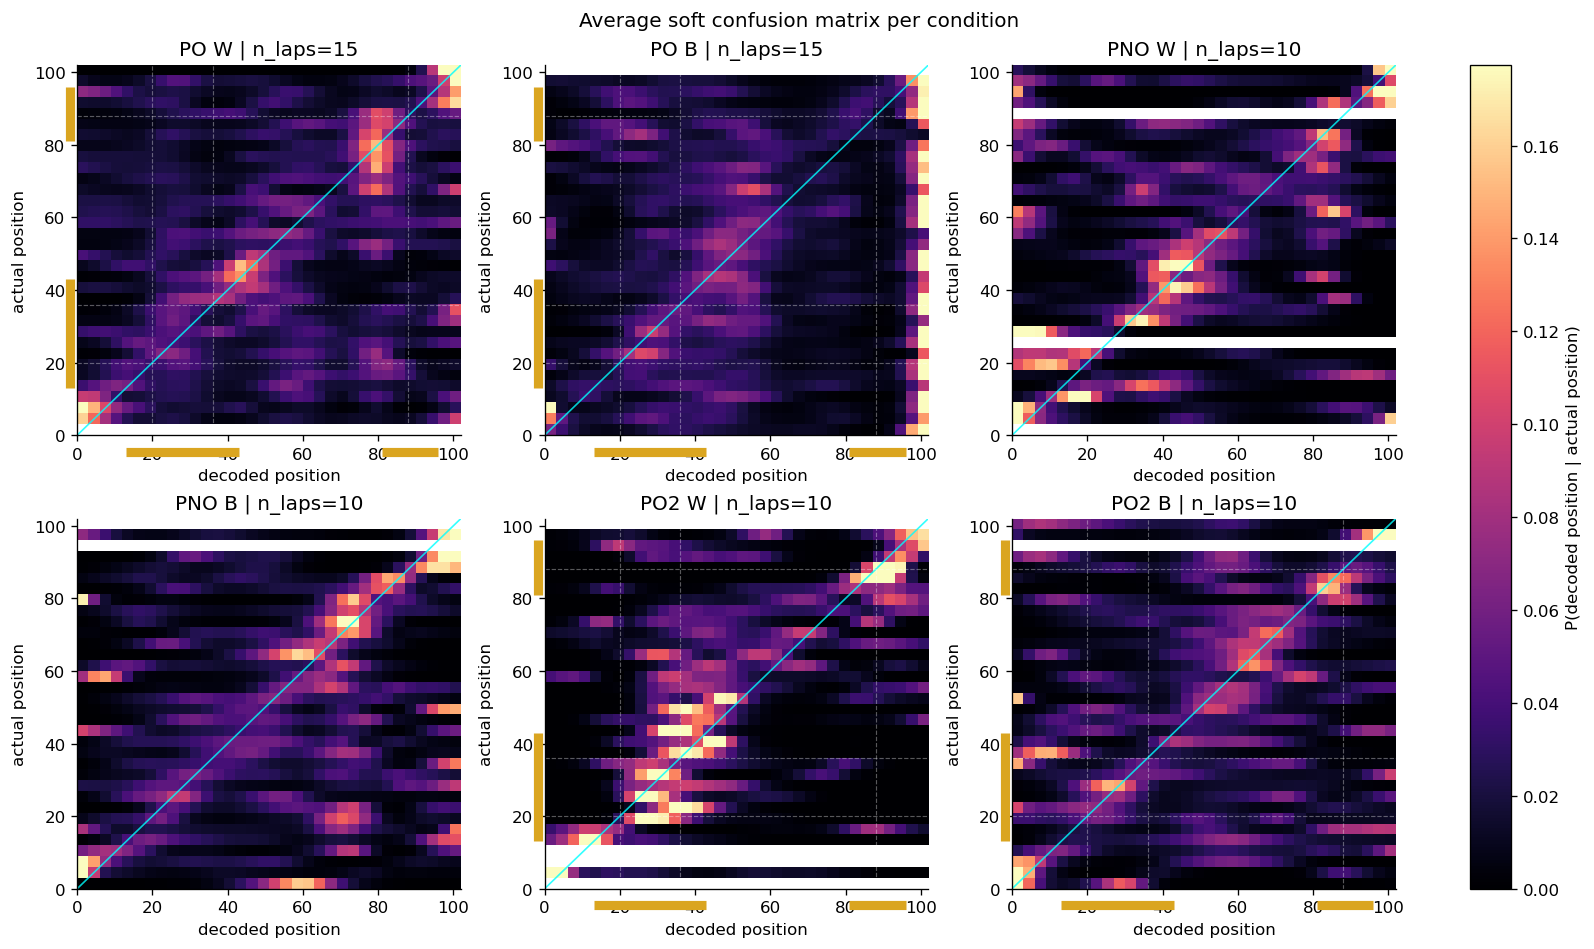

In [29]:
# Average soft confusion matrix: P(decoded position | actual position)
CONFUSION_CONDITION_LABELS = None  # None plots all condition-direction labels; or e.g. ['PO W', 'PO B']
CONFUSION_MAX_PANELS = 8
CONFUSION_NEAR_DIAGONAL_CM = 10.0
CONFUSION_SHOW_CUE_RICH_MARKERS = True
CONFUSION_SHOW_CUE_CENTER_LINES = True
CONFUSION_SHOW_RICH_LABELS = False


def trial_soft_confusion_matrix(result, window_idx, *, direction, flip_backward=False):
    n_bins = int(result.xbin_centers.size)
    window_idx = np.asarray(window_idx, dtype=np.int64)
    posterior = np.asarray(result.posterior_wx[window_idx], dtype=float)
    actual_bin = np.asarray(result.actual_bin_w[window_idx], dtype=np.int64)

    valid = (actual_bin >= 0) & (actual_bin < n_bins) & np.all(np.isfinite(posterior), axis=1)
    posterior = posterior[valid]
    actual_bin = actual_bin[valid]
    if posterior.shape[0] == 0:
        return np.full((n_bins, n_bins), np.nan), 0

    # For stored backward laps that increase from 0 to 100, show the common physical axis.
    if flip_backward and str(direction).upper() == 'B':
        posterior = posterior[:, ::-1]
        actual_bin = (n_bins - 1) - actual_bin

    accum = np.zeros((n_bins, n_bins), dtype=float)
    np.add.at(accum, actual_bin, posterior)

    # Each posterior vector already sums to 1 within a time window. This row normalization
    # converts summed posterior mass into P(decoded position | actual position bin).
    row_sums = accum.sum(axis=1, keepdims=True)
    matrix = np.full_like(accum, np.nan)
    valid_rows = row_sums[:, 0] > 0
    matrix[valid_rows] = accum[valid_rows] / row_sums[valid_rows]
    return matrix, int(posterior.shape[0])


def average_trial_confusions_by_condition(result, decode_df, context):
    work = decode_df.reset_index().rename(columns={'index': 'window_index'})
    flip_backward = should_flip_backward_for_context(context, TRACE_FLIP_BACKWARD_FOR_DISPLAY)
    matrices_by_label = {}
    trial_rows = []

    group_cols = ['trial_index', 'condway', 'condition_label', 'direction']
    for (trial_index, condway, label, direction), group in work.groupby(group_cols, sort=False):
        matrix, n_windows = trial_soft_confusion_matrix(
            result,
            group['window_index'].to_numpy(dtype=np.int64),
            direction=direction,
            flip_backward=flip_backward,
        )
        if n_windows == 0:
            continue
        label = str(label)
        matrices_by_label.setdefault(label, []).append(matrix)
        trial_rows.append(
            {
                'trial_index': int(trial_index),
                'condway': int(condway),
                'condition_label': label,
                'direction': str(direction),
                'n_windows': int(n_windows),
                'n_actual_bins': int(np.sum(np.any(np.isfinite(matrix), axis=1))),
            }
        )

    averages = {}
    for label, matrices in matrices_by_label.items():
        stack = np.stack(matrices, axis=0)
        counts = np.sum(np.isfinite(stack), axis=0)
        summed = np.nansum(stack, axis=0)
        avg = np.full_like(summed, np.nan)
        avg[counts > 0] = summed[counts > 0] / counts[counts > 0]
        averages[label] = avg

    return averages, pd.DataFrame(trial_rows)


def confusion_summary_frame(average_confusion_by_condition, trial_confusion_df, result):
    x = np.asarray(result.xbin_centers, dtype=float)
    distance_cm = np.abs(x[:, None] - x[None, :])
    near_mask = distance_cm <= float(CONFUSION_NEAR_DIAGONAL_CM)
    rows = []

    for label, matrix in average_confusion_by_condition.items():
        valid_rows = np.any(np.isfinite(matrix), axis=1)
        matrix_filled = np.nan_to_num(matrix, nan=0.0)
        diag = np.diag(matrix)
        near_mass_by_row = np.sum(matrix_filled * near_mask, axis=1)
        expected_abs_error_by_row = np.sum(matrix_filled * distance_cm, axis=1)
        with np.errstate(divide='ignore', invalid='ignore'):
            entropy_by_row = -np.sum(
                np.where(matrix_filled > 0, matrix_filled * np.log2(matrix_filled), 0.0),
                axis=1,
            )

        label_trials = trial_confusion_df[trial_confusion_df['condition_label'] == label]
        rows.append(
            {
                'condition_label': label,
                'n_trials': int(label_trials['trial_index'].nunique()),
                'n_windows': int(label_trials['n_windows'].sum()),
                'mean_diagonal_mass': float(np.nanmean(diag)) if np.any(np.isfinite(diag)) else np.nan,
                f'mean_near_diagonal_mass_{CONFUSION_NEAR_DIAGONAL_CM:g}cm': (
                    float(np.mean(near_mass_by_row[valid_rows])) if np.any(valid_rows) else np.nan
                ),
                'expected_abs_error_cm_from_matrix': (
                    float(np.mean(expected_abs_error_by_row[valid_rows])) if np.any(valid_rows) else np.nan
                ),
                'mean_row_entropy_bits': (
                    float(np.mean(entropy_by_row[valid_rows])) if np.any(valid_rows) else np.nan
                ),
            }
        )
    return pd.DataFrame(rows).sort_values('condition_label').reset_index(drop=True)


def draw_confusion_cue_markers(ax, layout, *, show_labels=False):
    if CONFUSION_SHOW_CUE_CENTER_LINES:
        for center in layout.object_centers:
            ax.axhline(center, color='white', ls='--', lw=0.7, alpha=0.35)
            ax.axvline(center, color='white', ls='--', lw=0.7, alpha=0.35)
    if not CONFUSION_SHOW_CUE_RICH_MARKERS:
        return
    for start, end in layout.rich_spans:
        # y-axis marker: actual-position cue-rich zone.
        ax.plot(
            [-0.018, -0.018],
            [start, end],
            transform=ax.get_yaxis_transform(),
            color='goldenrod',
            lw=5.5,
            solid_capstyle='butt',
            clip_on=False,
            zorder=8,
        )
        # x-axis marker: decoded-position cue-rich zone.
        ax.plot(
            [start, end],
            [-0.045, -0.045],
            transform=ax.get_xaxis_transform(),
            color='goldenrod',
            lw=5.5,
            solid_capstyle='butt',
            clip_on=False,
            zorder=8,
        )
        if show_labels:
            ax.text(-0.03, 0.5 * (start + end), 'rich', transform=ax.get_yaxis_transform(), va='center', ha='right', color='goldenrod', fontsize=8)
            ax.text(0.5 * (start + end), -0.085, 'rich', transform=ax.get_xaxis_transform(), va='top', ha='center', color='goldenrod', fontsize=8)


average_confusion_by_condition, trial_confusion_df = average_trial_confusions_by_condition(result, decode_df, context)
if not average_confusion_by_condition:
    raise RuntimeError('No confusion matrices could be built from the decoded windows.')

confusion_summary_df = confusion_summary_frame(average_confusion_by_condition, trial_confusion_df, result)
display(confusion_summary_df)

condition_order = [
    label for label in dict.fromkeys(decode_df['condition_label'].astype(str))
    if label in average_confusion_by_condition
]
if CONFUSION_CONDITION_LABELS is not None:
    requested = [str(label) for label in CONFUSION_CONDITION_LABELS]
    missing = [label for label in requested if label not in average_confusion_by_condition]
    if missing:
        print('Requested labels without decoded windows:', missing)
    condition_order = [label for label in requested if label in average_confusion_by_condition]

if CONFUSION_MAX_PANELS is not None and len(condition_order) > int(CONFUSION_MAX_PANELS):
    hidden = condition_order[int(CONFUSION_MAX_PANELS):]
    condition_order = condition_order[: int(CONFUSION_MAX_PANELS)]
    print(f'Plotting first {len(condition_order)} condition labels; hidden labels: {hidden}')
if not condition_order:
    raise RuntimeError('No condition labels selected for plotting.')

finite_values = np.concatenate([
    matrix[np.isfinite(matrix)].ravel()
    for label, matrix in average_confusion_by_condition.items()
    if np.any(np.isfinite(matrix))
])
vmax = min(1.0, max(0.05, float(np.nanpercentile(finite_values, 99))))
x_edges = np.asarray(result.xbin_edges, dtype=float)
x0, x1 = float(x_edges[0]), float(x_edges[-1])

n_cols = min(3, len(condition_order))
n_rows = int(math.ceil(len(condition_order) / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.9 * n_rows), constrained_layout=True, squeeze=False)
im = None
for ax, label in zip(axs.ravel(), condition_order):
    matrix = average_confusion_by_condition[label]
    im = ax.imshow(
        matrix,
        origin='lower',
        aspect='auto',
        interpolation='nearest',
        extent=[x0, x1, x0, x1],
        cmap='magma',
        vmin=0.0,
        vmax=vmax,
    )
    ax.plot([x0, x1], [x0, x1], color='cyan', lw=1.0, alpha=0.8)

    condways = trial_confusion_df.loc[trial_confusion_df['condition_label'] == label, 'condway'].dropna().unique()
    if condways.size:
        layout = cue_layout_for_condway(int(condways[0]), context['condition_name_map'])
        draw_confusion_cue_markers(ax, layout, show_labels=CONFUSION_SHOW_RICH_LABELS)

    n_trials = int(trial_confusion_df.loc[trial_confusion_df['condition_label'] == label, 'trial_index'].nunique())
    ax.set_title(f'{label} | n_laps={n_trials}')
    ax.set_xlabel('decoded position')
    ax.set_ylabel('actual position')

for ax in axs.ravel()[len(condition_order):]:
    ax.set_visible(False)

fig.suptitle('Average soft confusion matrix per condition')
fig.colorbar(im, ax=axs.ravel().tolist(), label='P(decoded position | actual position)')
plt.show()
